In [8]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from collections import deque
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.callbacks import ModelCheckpoint, TensorBoard

# ------------------- Seeds -------------------
np.random.seed(314)
tf.random.set_seed(314)
random.seed(314)

# ------------------- Constants -------------------
N_STEPS = 50
LOOKUP_STEP = 15
SCALE = True
SHUFFLE = True
SPLIT_BY_DATE = False
TEST_SIZE = 0.2
FEATURE_COLUMNS = ["open","high","low","close","adjclose","volume"]  # corrected

N_LAYERS = 2
CELL = LSTM
UNITS = 256
DROPOUT = 0.4
BIDIRECTIONAL = False

LOSS = "huber_loss"
OPTIMIZER = "adam"
BATCH_SIZE = 64
EPOCHS = 50

ticker = "AMZN"

# ------------------- File paths -------------------
date_now = pd.Timestamp.today().strftime("%Y-%m-%d")
ticker_data_filename = os.path.join("data", f"{ticker}_{date_now}.csv")

shuffle_str = f"sh-{int(SHUFFLE)}"
scale_str = f"sc-{int(SCALE)}"
split_by_date_str = f"sbd-{int(SPLIT_BY_DATE)}"

model_name = f"{date_now}_{ticker}-{shuffle_str}-{scale_str}-{split_by_date_str}-\
{LOSS}-{OPTIMIZER}-{CELL.__name__}-seq-{N_STEPS}-step-{LOOKUP_STEP}-layers-{N_LAYERS}-units-{UNITS}"
if BIDIRECTIONAL:
    model_name += "-b"

# ------------------- Load CSV -------------------
df = pd.read_csv("data/AMZN_2021-05-31.csv")  # <-- path to your CSV
df.rename(columns=lambda x: x.strip().lower(), inplace=True)

if 'date' not in df.columns:
    df['date'] = pd.to_datetime(df.index)

# ------------------- Helper functions -------------------
def shuffle_in_unison(a, b):
    state = np.random.get_state()
    np.random.shuffle(a)
    np.random.set_state(state)
    np.random.shuffle(b)

def load_data(ticker_df, n_steps=50, scale=True, shuffle=True, lookup_step=1,
              split_by_date=True, test_size=0.2, feature_columns=FEATURE_COLUMNS):
    df = ticker_df.copy()
    result = {"df": df.copy()}

    # validate feature columns
    for col in feature_columns:
        if col not in df.columns:
            raise ValueError(f"'{col}' does not exist in the dataframe.")

    if scale:
        column_scaler = {}
        for column in feature_columns:
            scaler = preprocessing.MinMaxScaler()
            df[column] = scaler.fit_transform(np.expand_dims(df[column].values, axis=1))
            column_scaler[column] = scaler
        result["column_scaler"] = column_scaler

    # target column
    df['future'] = df['adjclose'].shift(-lookup_step)
    last_sequence = np.array(df[feature_columns].tail(lookup_step))
    df.dropna(inplace=True)

    sequences = deque(maxlen=n_steps)
    sequence_data = []

    for entry, target in zip(df[feature_columns + ["date"]].values, df['future'].values):
        sequences.append(entry)
        if len(sequences) == n_steps:
            sequence_data.append([np.array(sequences), target])

    last_sequence = list([s[:len(feature_columns)] for s in sequences]) + list(last_sequence)
    result['last_sequence'] = np.array(last_sequence).astype(np.float32)

    X, y = [], []
    for seq, target in sequence_data:
        X.append(seq)
        y.append(target)

    X, y = np.array(X), np.array(y)

    if split_by_date:
        train_samples = int((1 - test_size) * len(X))
        result["X_train"], result["y_train"] = X[:train_samples], y[:train_samples]
        result["X_test"], result["y_test"] = X[train_samples:], y[train_samples:]
        if shuffle:
            shuffle_in_unison(result["X_train"], result["y_train"])
            shuffle_in_unison(result["X_test"], result["y_test"])
    else:
        result["X_train"], result["X_test"], result["y_train"], result["y_test"] = train_test_split(
            X, y, test_size=test_size, shuffle=shuffle
        )

    result["X_train"] = result["X_train"][:, :, :len(feature_columns)].astype(np.float32)
    result["X_test"] = result["X_test"][:, :, :len(feature_columns)].astype(np.float32)

    return result

data = load_data(df, n_steps=N_STEPS, scale=SCALE, split_by_date=SPLIT_BY_DATE,
                 shuffle=SHUFFLE, lookup_step=LOOKUP_STEP, test_size=TEST_SIZE,
                 feature_columns=FEATURE_COLUMNS)

# ------------------- Build model -------------------
def create_model(sequence_length, n_features, loss, units=256, cell=LSTM, n_layers=2,
                 dropout=0.4, optimizer="adam", bidirectional=False):
    model = Sequential()
    for i in range(n_layers):
        if i == 0:
            if bidirectional:
                model.add(Bidirectional(cell(units, return_sequences=True), input_shape=(sequence_length, n_features)))
            else:
                model.add(cell(units, return_sequences=True, input_shape=(sequence_length, n_features)))
        elif i == n_layers - 1:
            if bidirectional:
                model.add(Bidirectional(cell(units)))
            else:
                model.add(cell(units))
        else:
            if bidirectional:
                model.add(Bidirectional(cell(units, return_sequences=True)))
            else:
                model.add(cell(units, return_sequences=True))
        model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(loss=loss, optimizer=optimizer)
    return model

model = create_model(
    sequence_length=N_STEPS,
    n_features=len(FEATURE_COLUMNS),
    loss=LOSS,
    units=UNITS,
    cell=CELL,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    optimizer=OPTIMIZER,
    bidirectional=BIDIRECTIONAL
)






/Users/lasithcharuka/hand/stockpred-env/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/lasithcharuka/hand/stockpred-env/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/Users/lasithcharuka/hand/stockpred-env/lib/python3.13/site-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_

In [9]:
import os
from keras.callbacks import ModelCheckpoint, TensorBoard
import tensorflow as tf

# ------------------- Create results/logs directories -------------------
os.makedirs("results", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# ------------------- Define model name -------------------
model_name = f"{ticker}_{date_now}-seq-{N_STEPS}-step-{LOOKUP_STEP}-layers-{N_LAYERS}-units-{UNITS}"
if BIDIRECTIONAL:
    model_name += "-b"

# ------------------- Callbacks -------------------
# ModelCheckpoint: must end with .weights.h5 if saving only weights
checkpointer = ModelCheckpoint(
    os.path.join("results", model_name + ".weights.h5"),
    save_weights_only=True,
    save_best_only=True,
    verbose=1
)

tensorboard = TensorBoard(log_dir=os.path.join("logs", model_name))

# ------------------- Compile model with proper loss -------------------
LOSS = tf.keras.losses.Huber()  # fixed Huber loss
model.compile(loss=LOSS, optimizer=OPTIMIZER)

# ------------------- Train the model -------------------
history = model.fit(
    data["X_train"],
    data["y_train"],
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(data["X_test"], data["y_test"]),
    callbacks=[checkpointer, tensorboard],
    verbose=1
)




Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - loss: 0.0054
Epoch 1: val_loss improved from None to 0.00017, saving model to results/AMZN_2025-08-24-seq-50-step-15-layers-2-units-256.weights.h5
75/75 ━━━━━━━━━━━━━━━━━━━━ 23s 280ms/step - loss: 0.0019 - val_loss: 1.7360e-04
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 4.6673e-04
Epoch 2: val_loss did not improve from 0.00017
75/75 ━━━━━━━━━━━━━━━━━━━━ 22s 292ms/step - loss: 4.3611e-04 - val_loss: 4.5346e-04
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 4.8564e-04
Epoch 3: val_loss did not improve from 0.00017
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 236ms/step - loss: 4.5809e-04 - val_loss: 4.2720e-04
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 5.0474e-04
Epoch 4: val_loss did not improve from 0.00017
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 249ms/step - loss: 4.4900e-04 - val_loss: 1.9012e-04
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 3.7420e-04
Epoch 5: val_loss improved from 0.00017 to

In [18]:
def get_final_df(model, data):
    """
    Builds a dataframe with features, true prices, predicted prices, 
    and simulated buy/sell profits.
    """
    buy_profit  = lambda current, pred_future, true_future: true_future - current if pred_future > current else 0
    sell_profit = lambda current, pred_future, true_future: current - true_future if pred_future < current else 0

    X_test = data["X_test"]
    y_test = data["y_test"]

    # predictions
    y_pred = model.predict(X_test)

    # inverse scaling if used
    if SCALE:
        y_test = np.squeeze(data["column_scaler"]["adjclose"].inverse_transform(np.expand_dims(y_test, axis=0)))
        y_pred = np.squeeze(data["column_scaler"]["adjclose"].inverse_transform(y_pred))

    test_df = data["test_df"]

    # add predicted & true future prices
    test_df[f"adjclose_{LOOKUP_STEP}"] = y_pred
    test_df[f"true_adjclose_{LOOKUP_STEP}"] = y_test

    test_df.sort_index(inplace=True)
    final_df = test_df.copy()

    # calculate profits
    buy_profits = list(map(buy_profit, 
                           final_df["adjclose"], 
                           final_df[f"adjclose_{LOOKUP_STEP}"], 
                           final_df[f"true_adjclose_{LOOKUP_STEP}"]))
    sell_profits = list(map(sell_profit, 
                            final_df["adjclose"], 
                            final_df[f"adjclose_{LOOKUP_STEP}"], 
                            final_df[f"true_adjclose_{LOOKUP_STEP}"]))

    # pad with zero (last sequence has no profit)
    buy_profits.append(0)
    sell_profits.append(0)

    final_df["buy_profit"] = buy_profits[:len(final_df)]
    final_df["sell_profit"] = sell_profits[:len(final_df)]

    return final_df


In [12]:
def predict(model, data):
    # retrieve the last sequence from data
    last_sequence = data["last_sequence"][-N_STEPS:]
    # expand dimension
    last_sequence = np.expand_dims(last_sequence, axis=0)
    # get the prediction (scaled from 0 to 1)
    prediction = model.predict(last_sequence)
    # get the price (by inverting the scaling)
    if SCALE:
        predicted_price = data["column_scaler"]["adjclose"].inverse_transform(prediction)[0][0]
    else:
        predicted_price = prediction[0][0]
    return predicted_price

In [13]:
# correct path to the saved weights
model_path = os.path.join("results", model_name) + ".weights.h5"

# load the weights
model.load_weights(model_path)


In [14]:
# Recompile the model to include MAE metric
model.compile(
    loss="huber",
    optimizer=OPTIMIZER,
    metrics=["mae"]
)

# Evaluate the model
loss, mae = model.evaluate(data["X_test"], data["y_test"], verbose=0)

# If scaling was applied, inverse transform the MAE to original price units
if SCALE:
    # reshape mae to 2D array to match scaler input
    mean_absolute_error = data["column_scaler"]["adjclose"].inverse_transform([[mae]])[0][0]
else:
    mean_absolute_error = mae

print(f"Test Loss: {loss:.4f}")
print(f"Mean Absolute Error (original scale): {mean_absolute_error:.4f}")


Test Loss: 0.0001
Mean Absolute Error (original scale): 27.9857


In [15]:
# Get the last portion of the original dataframe for testing
test_df = df.tail(len(data["X_test"])).copy()
data["test_df"] = test_df

# Now this will work
final_df = get_final_df(model, data)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


In [16]:
# predict the future price
future_price = predict(model, data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [20]:
import matplotlib.pyplot as plt

def plot_results(final_df):
    """
    Plots:
    1. True vs Predicted Adj Close Prices (line chart)
    2. Buy and Sell Profits per Trade (bar chart)
    """
    fig, ax1 = plt.subplots(figsize=(14,6))

    # -------- Line Chart --------
    ax1.plot(final_df[f'true_adjclose_{LOOKUP_STEP}'], color='b', label="Actual Price")
    ax1.plot(final_df[f'adjclose_{LOOKUP_STEP}'], color='r', label="Predicted Price")
    ax1.set_xlabel("Days")
    ax1.set_ylabel("Price ($)")
    ax1.legend(loc='upper left')

    # -------- Bar Chart --------
    ax2 = ax1.twinx()  # second y-axis for profits
    ax2.bar(final_df.index, final_df["buy_profit"], color='g', alpha=0.4, label="Buy Profit")
    ax2.bar(final_df.index, final_df["sell_profit"], color='r', alpha=0.3, label="Sell Profit")
    ax2.set_ylabel("Profit ($)")
    ax2.legend(loc='upper right')

    plt.title("Stock Price Prediction vs Actual & Profit per Trade")
    plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step


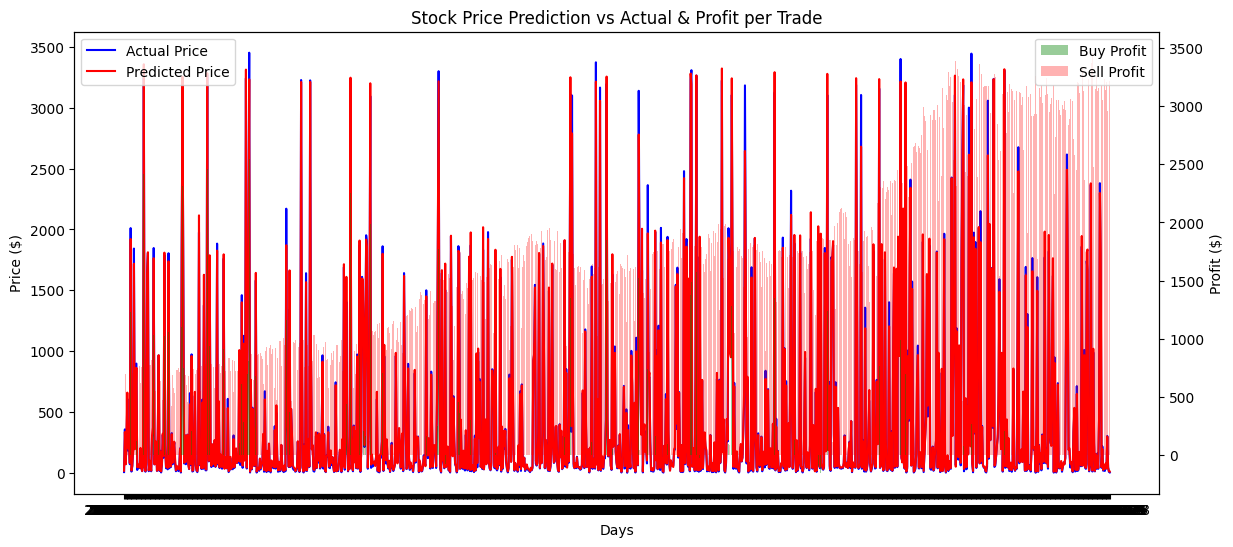

In [21]:
final_df = get_final_df(model, data)
plot_results(final_df)


In [ ]:
final_df.head(20)

,open,high,low,close,adjclose,volume,ticker,date,adjclose_15,true_adjclose_15,buy_profit,sell_profit
2016-08-25,756.000000,760.559998,754.739990,759.219971,759.219971,1623000,AMZN,2016-08-25,18.634661,7.708333,0.000000,751.511638
2016-08-26,760.049988,770.000000,759.799988,769.000000,769.000000,2776800,AMZN,2016-08-26,335.997345,358.140015,0.000000,410.859985
2016-08-29,768.719971,774.979980,768.599976,771.289978,771.289978,2198600,AMZN,2016-08-29,71.059586,75.000000,0.000000,696.289978
2016-08-30,771.049988,771.840027,765.559998,767.580017,767.580017,1709200,AMZN,2016-08-30,268.562378,250.600006,0.000000,516.980011
2016-08-31,766.599976,769.640015,764.000000,769.159973,769.159973,1633800,AMZN,2016-08-31,659.989502,607.940002,0.000000,161.219971
2016-09-01,770.900024,772.039978,766.750000,770.619995,770.619995,1792300,AMZN,2016-09-01,201.005524,182.500000,0.000000,588.119995
2016-09-02,774.109985,776.000000,771.700012,772.440002,772.440002,2181800,AMZN,2016-09-02,326.876465,310.489990,0.000000,461.950012
2016-09-06,774.039978,789.479980,770.219971,788.869995,788.869995,3719800,AMZN,2016-09-06,82.403419,72.379997,0.000000,716.489998
2016-09-07,789.530029,790.789978,784.330017,784.479980,784.479980,2424600,AMZN,2016-09-07,1921.440063,2011.000000,1226.520020,0.000000
2016-09-08,783.890015,786.500000,781.440002,784.059998,784.059998,2030500,AMZN,2016-09-08,20.972342,11.875000,0.000000,772.184998


In [ ]:
final_df.tail(20)

,open,high,low,close,adjclose,volume,ticker,date,adjclose_15,true_adjclose_15,buy_profit,sell_profit
2021-05-03,3484.729980,3486.649902,3372.699951,3386.489990,3386.489990,5875500,AMZN,2021-05-03,246.751831,247.110001,0.0,3139.379990
2021-05-04,3356.189941,3367.979980,3272.129883,3311.870117,3311.870117,5439400,AMZN,2021-05-04,17.098106,13.300000,0.0,3298.570117
2021-05-05,3338.860107,3354.699951,3264.360107,3270.540039,3270.540039,3711300,AMZN,2021-05-05,155.432907,126.279999,0.0,3144.260040
2021-05-06,3270.000000,3314.399902,3247.199951,3306.370117,3306.370117,4447700,AMZN,2021-05-06,42.236954,34.820000,0.0,3271.550117
2021-05-07,3319.090088,3330.889893,3289.070068,3291.610107,3291.610107,4706800,AMZN,2021-05-07,139.627563,160.729996,0.0,3130.880112
2021-05-10,3282.320068,3283.000000,3190.000000,3190.489990,3190.489990,5838600,AMZN,2021-05-10,42.090168,34.599998,0.0,3155.889992
2021-05-11,3136.280029,3238.000000,3127.370117,3223.909912,3223.909912,4619800,AMZN,2021-05-11,438.713715,436.589996,0.0,2787.319916
2021-05-12,3185.000000,3207.939941,3133.100098,3151.939941,3151.939941,4936400,AMZN,2021-05-12,2298.951660,2379.610107,0.0,772.329834
2021-05-13,3185.469971,3203.840088,3133.000000,3161.469971,3161.469971,3350900,AMZN,2021-05-13,1811.742554,1665.530029,0.0,1495.939941
2021-05-14,3185.560059,3228.860107,3183.000000,3222.899902,3222.899902,3321400,AMZN,2021-05-14,48.582687,42.437500,0.0,3180.462402


In [ ]:
# save the final dataframe to csv-results folder
csv_results_folder = "csv-results"
if not os.path.isdir(csv_results_folder):
    os.mkdir(csv_results_folder)
csv_filename = os.path.join(csv_results_folder, model_name + ".csv")
final_df.to_csv(csv_filename)